In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Face_Cropping_Project"
)
DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGE_DIR = DATASET_DIR / "images"
CSV_PATH = DATASET_DIR / "faces.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
print("Project:", PROJECT_ROOT)
print("Images:", IMAGE_DIR)
print("CSV:", CSV_PATH)
print("Outputs:", OUTPUT_DIR)

Project: /content/drive/MyDrive/Face_Cropping_Project
Images: /content/drive/MyDrive/Face_Cropping_Project/dataset/images
CSV: /content/drive/MyDrive/Face_Cropping_Project/dataset/faces.csv
Outputs: /content/drive/MyDrive/Face_Cropping_Project/outputs


In [3]:
print("Project exists :", PROJECT_ROOT.exists())
print("Dataset exists :", DATASET_DIR.exists())
print("Images exist  :", IMAGE_DIR.exists())
print("CSV exists     :", CSV_PATH.exists())

Project exists : True
Dataset exists : True
Images exist  : True
CSV exists     : True


In [4]:
!pip install -q pandas numpy pillow matplotlib tqdm scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (3350, 7)

Columns:
['image_name', 'width', 'height', 'x0', 'y0', 'x1', 'y1']


,image_name,width,height,x0,y0,x1,y1
0,00001722.jpg,1333,2000,490,320,687,664
1,00001044.jpg,2000,1333,791,119,1200,436
2,00001050.jpg,667,1000,304,155,407,331
3,00001736.jpg,626,417,147,14,519,303
4,00003121.jpg,626,418,462,60,599,166


In [7]:
print("Number of annotation rows:", len(df))
print("Number of unique images:", df["image_name"].nunique())
print("Number of faces:", len(df))
faces_per_image = df.groupby("image_name").size()
print("\nFaces per image:")
print(faces_per_image.describe())

Number of annotation rows: 3350
Number of unique images: 2204
Number of faces: 3350

Faces per image:
count    2204.000000
mean        1.519964
std         1.267299
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        12.000000
dtype: float64


In [8]:
print(df.isnull().sum())

image_name    0
width         0
height        0
x0            0
y0            0
x1            0
y1            0
dtype: int64


In [9]:
invalid_boxes = df[
    (df["x0"] < 0) |
    (df["y0"] < 0) |
    (df["x1"] > df["width"]) |
    (df["y1"] > df["height"]) |
    (df["x0"] >= df["x1"]) |
    (df["y0"] >= df["y1"])
]
print("Invalid bounding boxes:", len(invalid_boxes))
if len(invalid_boxes) > 0:
    display(invalid_boxes.head())

Invalid bounding boxes: 0


In [10]:
image_files = {
    p.name for p in IMAGE_DIR.iterdir()
    if p.is_file()
}
df["image_exists"] = df["image_name"].isin(image_files)
print("Annotations with existing images:",
      df["image_exists"].sum())
print("Annotations with missing images:",
      (~df["image_exists"]).sum())

Annotations with existing images: 3350
Annotations with missing images: 0


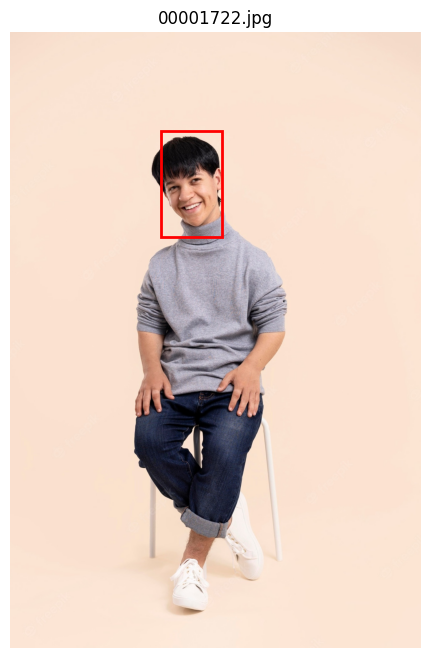

In [11]:
import matplotlib.patches as patches
sample_row = df.iloc[0]
image_path = IMAGE_DIR / sample_row["image_name"]
image = Image.open(image_path).convert("RGB")
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image)
rect = patches.Rectangle(
    (sample_row["x0"], sample_row["y0"]),
    sample_row["x1"] - sample_row["x0"],
    sample_row["y1"] - sample_row["y0"],
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)
ax.add_patch(rect)
ax.set_title(sample_row["image_name"])
ax.axis("off")
plt.show()

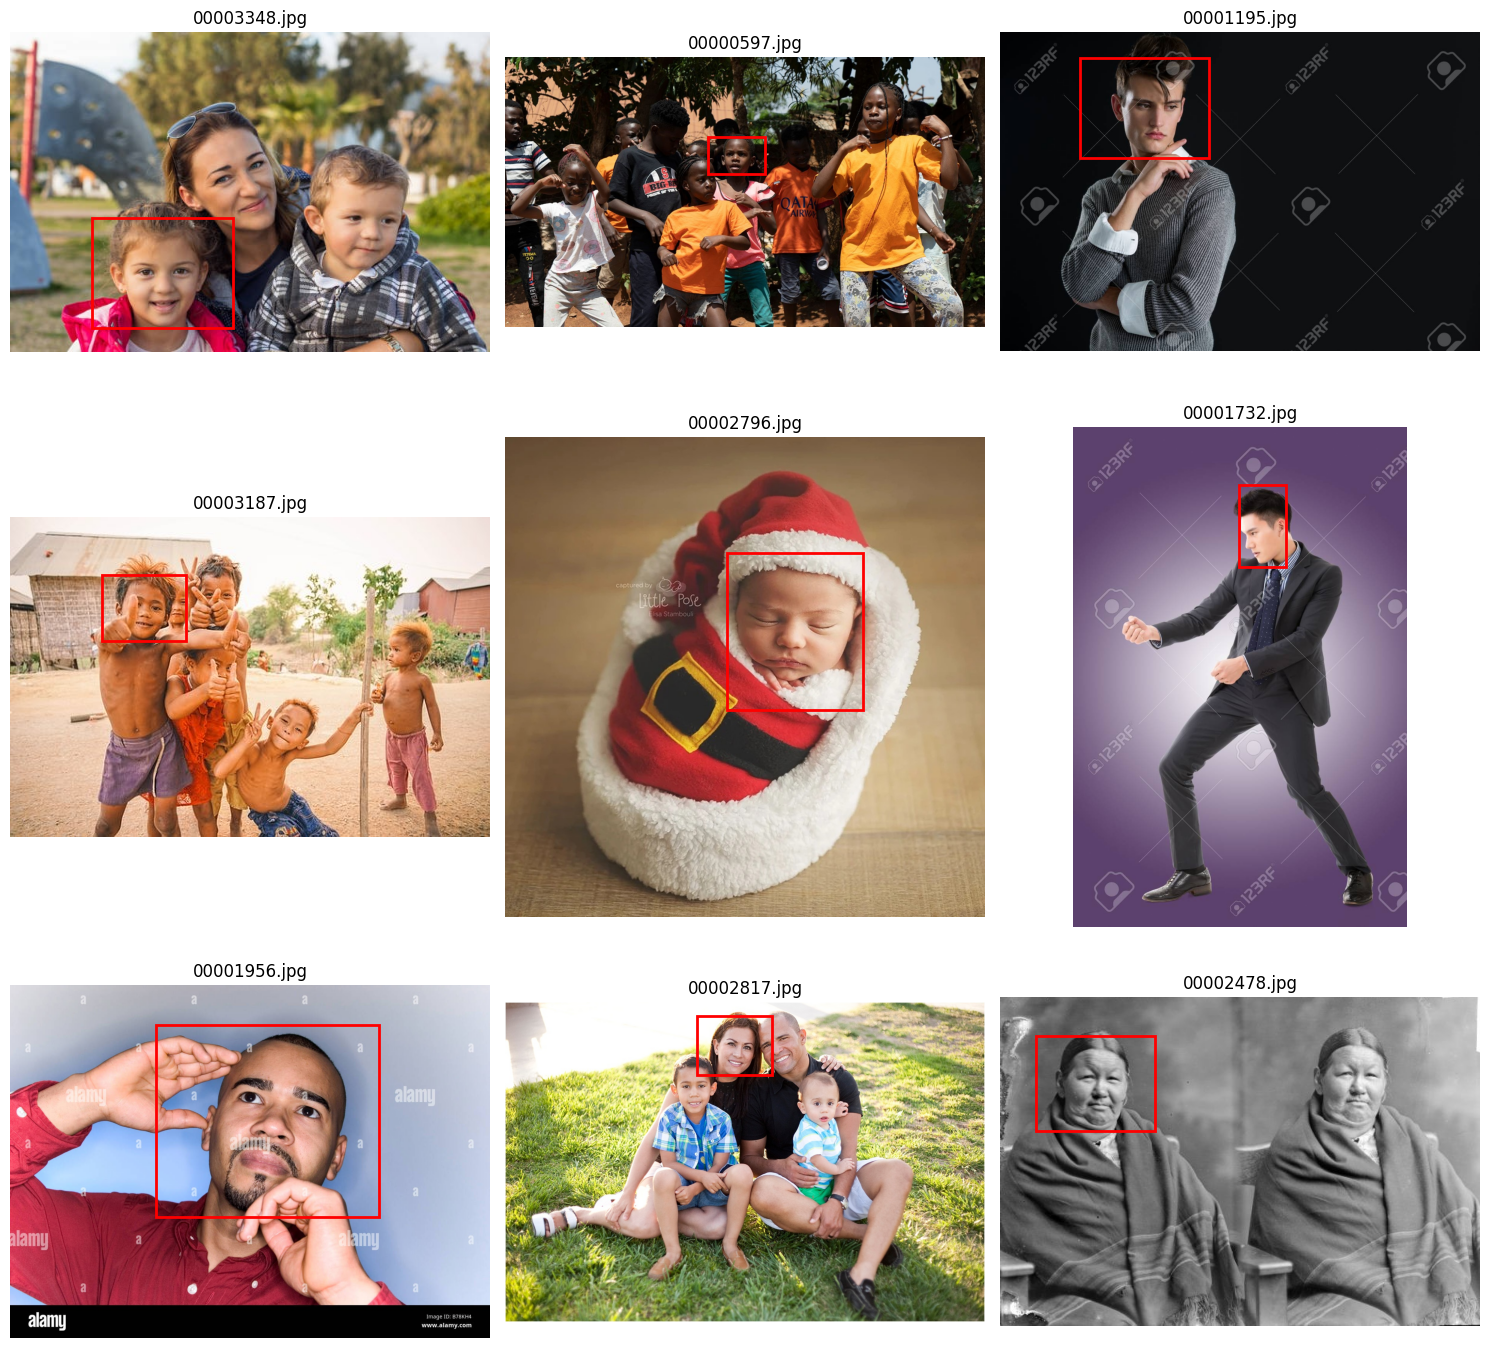

In [12]:
sample_df = df.sample(
    n=min(9, len(df)),
    random_state=42
)
fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 15)
)
axes = axes.flatten()
for ax, (_, row) in zip(axes, sample_df.iterrows()):

    image_path = IMAGE_DIR / row["image_name"]
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    rect = patches.Rectangle(
        (row["x0"], row["y0"]),
        row["x1"] - row["x0"],
        row["y1"] - row["y0"],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(row["image_name"])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
GROUND_TRUTH_DIR = OUTPUT_DIR / "ground_truth_faces"
GROUND_TRUTH_DIR.mkdir(
    parents=True,
    exist_ok=True
)
print(GROUND_TRUTH_DIR)

/content/drive/MyDrive/Face_Cropping_Project/outputs/ground_truth_faces


In [17]:
from PIL import Image

successful = 0
failed = 0

for idx, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Creating ground-truth crops"
):

    try:
        image_path = IMAGE_DIR / row["image_name"]

        image = Image.open(image_path).convert("RGB")

        x0 = int(row["x0"])
        y0 = int(row["y0"])
        x1 = int(row["x1"])
        y1 = int(row["y1"])

        face = image.crop((x0, y0, x1, y1))

        output_name = (
            f"{Path(row['image_name']).stem}"
            f"_face_{idx:05d}.jpg"
        )

        output_path = GROUND_TRUTH_DIR / output_name

        face.save(output_path, quality=95)

        successful += 1

    except Exception as e:
        failed += 1
        print(
            f"Failed: {row['image_name']} | {e}"
        )

print("\nCompleted")
print("Successful:", successful)
print("Failed:", failed)

Creating ground-truth crops:   0%|          | 0/3350 [00:00<?, ?it/s]


Completed
Successful: 3350
Failed: 0


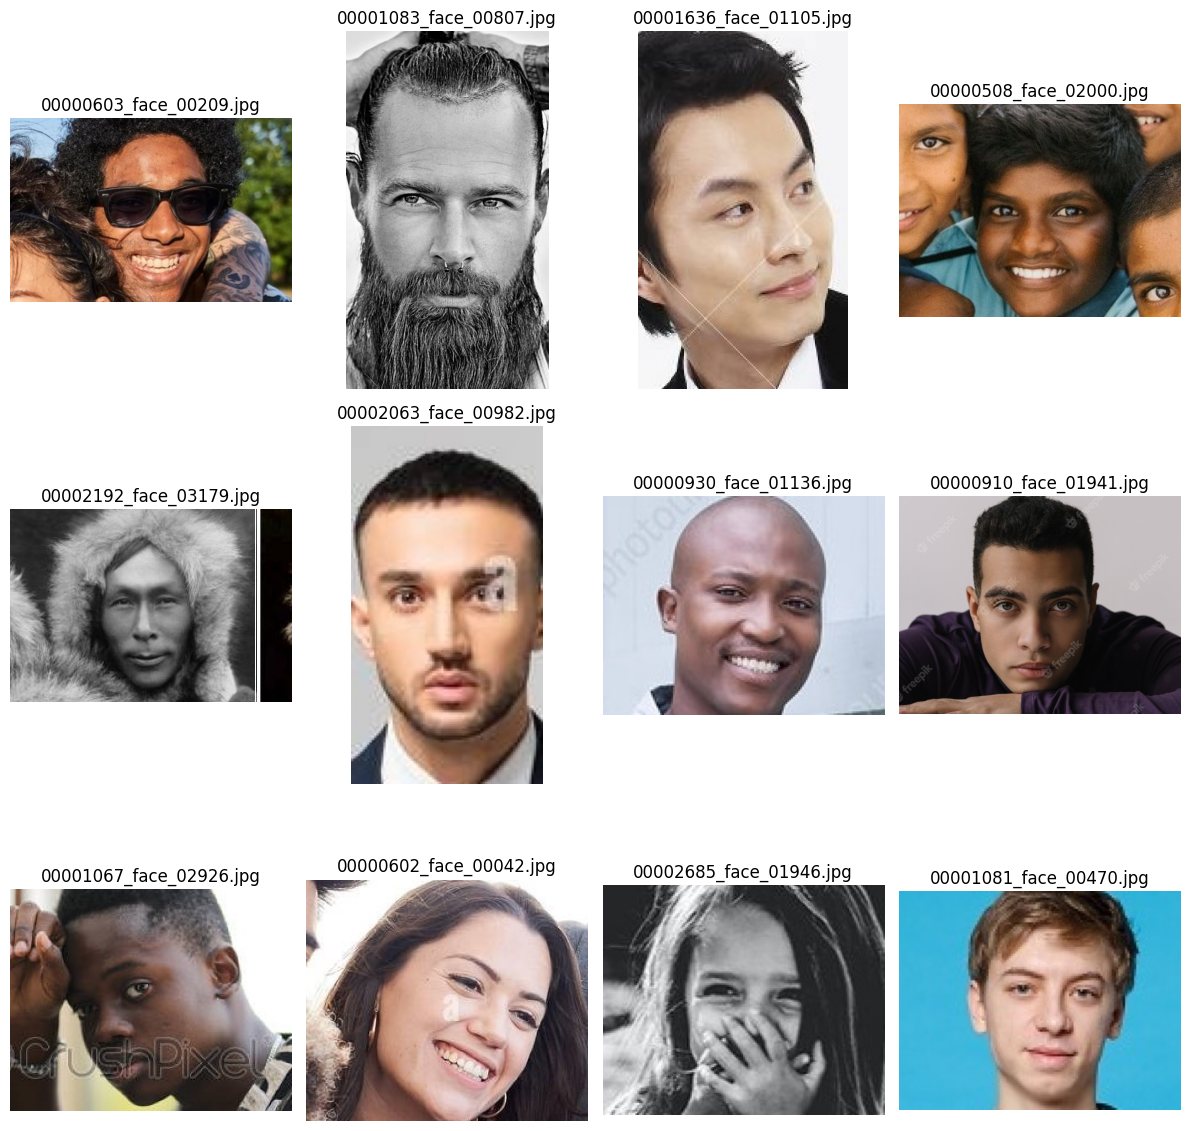

In [18]:
crop_files = list(GROUND_TRUTH_DIR.glob("*.jpg"))

sample_crops = np.random.choice(
    crop_files,
    size=min(12, len(crop_files)),
    replace=False
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 12)
)

axes = axes.flatten()

for ax, crop_path in zip(axes, sample_crops):

    face = Image.open(crop_path)

    ax.imshow(face)
    ax.set_title(crop_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
unique_images = df["image_name"].unique()

train_images, temp_images = train_test_split(
    unique_images,
    test_size=0.30,
    random_state=42
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=42
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Train images: 1542
Validation images: 331
Test images: 331


In [20]:
train_set = set(train_images)
val_set = set(val_images)
test_set = set(test_images)

print("Train ∩ Val:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test:", len(val_set & test_set))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [21]:
 split_df = pd.DataFrame({
    "image_name": (
        list(train_images)
        + list(val_images)
        + list(test_images)
    ),
    "split": (
        ["train"] * len(train_images)
        + ["val"] * len(val_images)
        + ["test"] * len(test_images)
    )
})

split_path = DATASET_DIR / "image_splits.csv"

split_df.to_csv(
    split_path,
    index=False
)

print("Saved:", split_path)
display(split_df.head())

Saved: /content/drive/MyDrive/Face_Cropping_Project/dataset/image_splits.csv


,image_name,split
0,00001545.jpg,train
1,00000665.jpg,train
2,00002385.jpg,train
3,00001079.jpg,train
4,00003437.jpg,train


In [22]:
print("========== DATASET SUMMARY ==========")

print(f"Annotation rows : {len(df)}")
print(f"Unique images   : {df['image_name'].nunique()}")

print("\nImage splits:")
print(split_df["split"].value_counts())

print("\nFaces by split:")

split_lookup = dict(
    zip(
        split_df["image_name"],
        split_df["split"]
    )
)

df["split"] = df["image_name"].map(split_lookup)

print(df["split"].value_counts())

print("\nBounding box statistics:")

df["box_width"] = df["x1"] - df["x0"]
df["box_height"] = df["y1"] - df["y0"]

print(df[[
    "box_width",
    "box_height"
]].describe())

========== DATASET SUMMARY ==========
Annotation rows : 3350
Unique images   : 2204

Image splits:
split
train    1542
val       331
test      331
Name: count, dtype: int64

Faces by split:
split
train    2348
test      510
val       492
Name: count, dtype: int64

Bounding box statistics:
         box_width   box_height
count  3350.000000  3350.000000
mean    246.592537   238.866866
std     211.036274   210.941092
min      29.000000    34.000000
25%     112.000000   110.000000
50%     185.000000   177.000000
75%     303.000000   292.000000
max    2565.000000  3439.000000
